In [9]:
from module import Value
import random

In [10]:
#This is the code for the visulize the Value object. Draw function will return a graphical representation of the full network.
from graphviz import Digraph
import math

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw(root):
    dot = Digraph(format= 'svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{%s | data %.4f | %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot



In [11]:
class Neuron:
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
    
    def __call__(self, x):
        activision = sum ((wk*xk for wk, xk in zip(self.w, x)) , self.b)
        out = activision.sigmoid()
        return out
    
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [ Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        out = [ n(x) for n in self.neurons ]
        #when we are getting the output in the MLP we would get a list of a Value object, which is not what we wanted.
        #If you try to draw it will give you error as the root is a list not Value object.
        return out[0] if len(out) == 1 else out

class MLP:

    def __init__(self, nin, nlist):
        size = [nin] + nlist
        self.layers = [ Layer(size[idx], size[idx+1]) for idx in range(len(nlist))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [13]:
A = MLP(3, [4,4,1])
input = [2.0,3.0,4.0]
A(input)

Value(data=0.42643053870608044)

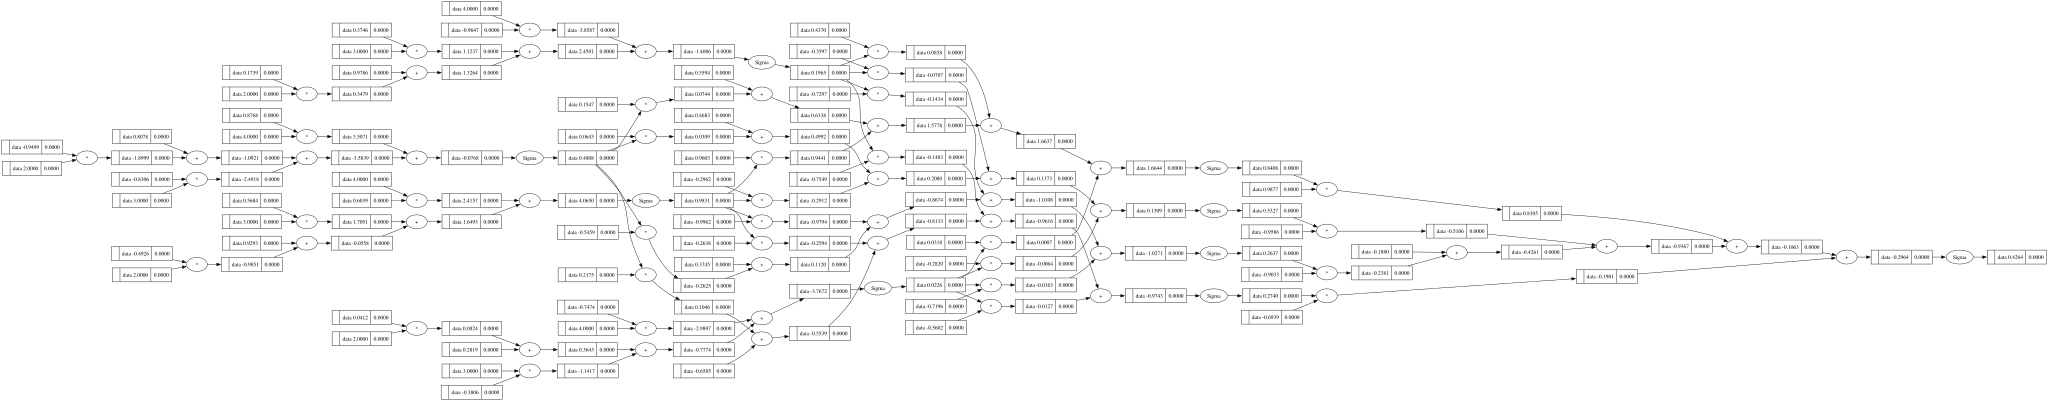

In [15]:
draw(A(input))